In [5]:
import numpy as np                      # Importing numpy
import matplotlib.pyplot as plt         # Importing matplotlib.pyplot
from RandomTilings import draw_aztec,draw_dominos,weight_aztec,weight_hexagon
#from RandomTilings import draw_lozenges,draw_hexagon           # Importing Important routines
#from RandomTilings.algorithm_reduction_weight import algorithm_reduction_weight
#from RandomTilings.shuffling import shuffling as shuffling0

#from RandomTilings import draw_aztec_gap

# Jupyter workaround to avoid a doubled display of the images
plt.figure()
plt.close()
_ = plt.ioff()

from numba import jit
import numba

In [98]:
@jit("(float64, float64, float64, float64)")
def red_cases_tmp(w,x,y,z): # at most one value is 0 !!!
    # tmp_w = w/(w*z+x*y)
    if w == 0:
        tmp_w = 0
    elif z == 0:
        tmp_w = w/(x*y)
    elif x == 0 or y == 0:
        tmp_w = 1/z
    elif np.isinf(w): # what if multiple values are inf !!!
        tmp_w = 1/z
    elif np.isinf(x) or np.isinf(y) or np.isinf(z):
        tmp_w = 0
    else:
        tmp_w = w/(w*z+x*y)
    return tmp_w


# @jit("(float64, float64, float64, float64)")
# def red_cases_tmp(w,x,y,z): # at most one value is 0 !!!
#     # tmp_w = w/(w*z+x*y)
#     infty = sum([np.isinf(w),np.isinf(x),np.isinf(y),np.isinf(z)]) 
#     if infty==0:
#         tmp = w*z+x*y
#         return z/tmp,y/tmp,x/tmp,w/tmp
#     elif infty>2:
#         return 1/2**0.5,1/2**0.5,1/2**0.5,1/2**0.5
#     elif (np.isinf(z) and np.isinf(w)) or (np.isinf(x) and np.isinf(y)):
#         return 1/2**0.5,1/2**0.5,1/2**0.5,1/2**0.5
#     # maybe we need to memic the behavior of the classic red_cases???
#     elif np.isinf(w) and np.isinf(x):
#         return 0,0,1/(z+y),1/(z+y)
#     elif np.isinf(x) and np.isinf(z):
#         return 1/(w+y),0,1/(w+y),0
#     elif np.isinf(z) and np.isinf(y):
#         return 1/(x+w),1/(x+w),0,0
#     elif np.isinf(w) and np.isinf(y):
#         return 0,1/(x+z),1/(x+z),0
#     elif np.isinf(w):
#         if z==0:
#             return 0,1/x,1/y,np.inf
#         else:
#             return 0,0,0,1/z
        
#     elif np.isinf(z):
#         if w==0:
#             return np.inf,1/x,1/y,0
#         else:
#             return 1/w,0,0,0
        
#     elif np.isinf(x):
#         if y==0:
#             return 1/w,0,np.inf,1/z
#         else:
#             return 0,0,1/y,0
        
#     elif np.isinf(y):
#         if x==0:
#             return 1/w,np.inf,0,1/z
#         else:
#             return 0,1/x,0,0




@jit("(float64, float64, float64, float64)")
def red_cases(w,x,y,z):
    if w+x+y+z == 0:
        return 1/2**0.5,1/2**0.5,1/2**0.5,1/2**0.5
    elif z+x==0:
        return 1/(w+y),y,1/(w+y),w
    elif w+x==0:
        return z,y,1/(z+y),1/(z+y)
    elif w+y==0:
        return z,1/(z+x),x,1/(z+x)
    elif z+y==0:
        return 1/(x+w),1/(x+w),x,w
    else:
        # return red_cases_tmp(w,x,y,z)
        # tmp_w = w/(w*z+x*y)
        # tmp_x = x/(x*y+w*z) # w <-> x, y <-> z
        # tmp_y = y/(y*x+z*w) # w <-> y, x <-> z
        # tmp_z = z/(z*w+x*y) # w <-> z
        tmp_w = red_cases_tmp(w,x,y,z)
        tmp_x = red_cases_tmp(x,w,z,y) # w <-> x, y <-> z
        tmp_y = red_cases_tmp(y,z,w,x) # w <-> y, x <-> z
        tmp_z = red_cases_tmp(z,x,y,w) # w <-> z
        return tmp_z, tmp_y, tmp_x, tmp_w

@jit(["(Array(float64, 2, 'C', False, aligned=True),boolean)","(Array(float64, 2, 'A', False, aligned=True),boolean)"])
def reduction(W,debug):
    N = W.shape[0]
    W_red = np.zeros((N,N))

    if debug:
        print('input reduction')
        print(W)

    for m in range(N//2):
        for n in range(N//2):
            w,x,y,z = W[2*m,2*n],W[2*m,2*n+1],W[2*m+1,2*n],W[2*m+1,2*n+1]
            p,q,r,s = red_cases(w,x,y,z)
            W_red[2*m,2*n]     = p
            W_red[2*m,2*n+1]   = q
            W_red[2*m+1,2*n]   = r
            W_red[2*m+1,2*n+1] = s

    if debug:
        print('classical reduction')
        print(W_red)

    for m in range(N//2):
        for n in range(N//2):
            w,x,y,z = W[2*m,2*n],W[2*m,2*n+1],W[2*m+1,2*n],W[2*m+1,2*n+1]
            if w+x == 0:
                W_red[2*m-1,2*n],W_red[2*m-1,2*n+1]=0,0
            if x+z == 0:
                W_red[2*m,2*n+2],W_red[2*m+1,2*n+2]=0,0
            if y+z == 0:
                W_red[2*m+2,2*n],W_red[2*m+2,2*n+1]=0,0
            if w+y == 0:
                W_red[2*m,2*n-1],W_red[2*m+1,2*n-1]=0,0

    if debug:
        print('double zero step')
        print(W_red)

        print('output reduction')
        print(W_red[1:-1,1:-1])
        print()
                
    return W_red[1:-1,1:-1]

def reduce_weight(W):
    n = W.shape[0]//2
    C = n*[np.zeros((0,0))]
    C[n-1] = W
    for i in range(2,n+1):
        if np.isnan(C[n-(i-1)]).any():
            C[n-i] = reduction(C[n-(i-1)],True)
        else:
            C[n-i] = reduction(C[n-(i-1)],False)
    return C

def reduce_weight_first_error(W):
    n = W.shape[0]//2
    C = n*[np.zeros((0,0))]
    C[n-1] = W
    for i in range(2,n+1):
        if np.isnan(C[n-(i-1)]).any():
            print('BREAKS')
            return C[n-(i-2)]
        else:
            C[n-i] = reduction(C[n-(i-1)],False)
    return C

@jit( "(Array(int8, 2, 'C', False, aligned=True), int64, int64, int64)")
def no_neighbor(M,k,m,n):
    N = M.shape[0]
    A = N//2-1-k  
    
    if M[A+2*m,A+2*n]+M[A+2*m+1,A+2*n]+M[A+2*m,A+2*n+1]+M[A+2*m+1,A+2*n+1]>0:
        return False

    if n==0:
        tmp_w = True
        tmp_e = (M[A+2*m,A+2*(n+1)]+M[A+2*m+1,A+2*(n+1)])==0
    elif n==k:
        tmp_w = (M[A+2*m,A+2*n-1]+M[A+2*m+1,A+2*n-1])==0
        tmp_e = True
    else:
        tmp_w = (M[A+2*m,A+2*n-1]+M[A+2*m+1,A+2*n-1])==0
        tmp_e = (M[A+2*m,A+2*(n+1)]+M[A+2*m+1,A+2*(n+1)])==0

    if m==0:
        tmp_n = True
        tmp_s = (M[A+2*(m+1),A+2*n]+M[A+2*(m+1),A+2*n+1])==0
    elif m==k:
        tmp_n = (M[A+2*m-1,A+2*n]+M[A+2*m-1,A+2*n+1])==0
        tmp_s = True
    else:
        tmp_n = (M[A+2*m-1,A+2*n]+M[A+2*m-1,A+2*n+1])==0
        tmp_s = (M[A+2*(m+1),A+2*n]+M[A+2*(m+1),A+2*n+1])==0

    return tmp_s and tmp_e and tmp_w and tmp_n

@jit("(ListType(Array(float64, 2, 'A')),)")
def shuffling(C):
    N = 2*len(C)
    M = np.zeros((N,N),dtype=np.int8)

    # Initiate
    A = N//2-1
    w,x,y,z = C[0][0,0],C[0][0,1],C[0][1,0],C[0][1,1]

    #prob = (w*z)/(w*z+x*y)
    if w == 0:
        if z == 0:
            prob = 0
        elif x == 0:
            prob = z/(z+y)
        elif y == 0:
            prob = z/(z+x)
        else:
            prob = 0
    elif z == 0:
        if x == 0:
            prob = w/(w+y)
        elif y == 0:
            prob = w/(w+x)
        else:
            prob = 0
    elif x == 0 or y == 0:
        prob = 1
    elif np.isinf(w) or np.isinf(z):
        prob = 1
    elif np.isinf(x) or np.isinf(y):
        prob = 0
    else:
        prob = (w*z)/(w*z+x*y)
    if np.random.random()<prob:
        M[A,A],M[A+1,A+1]= 1,1
        M[A,A+1],M[A+1,A]= 0,0
    else:
        M[A,A],M[A+1,A+1]= 0,0
        M[A,A+1],M[A+1,A]= 1,1

    for k in range(1,N//2):
        A = N//2-1-k   

        # destruction + flip
        for m in range(k+1):
            for n in range(k+1):
                tmp = M[A+2*m,A+2*n]+M[A+2*m+1,A+2*n]+M[A+2*m,A+2*n+1]+M[A+2*m+1,A+2*n+1]
                if tmp>1:
                    M[A+2*m,A+2*n],M[A+2*m+1,A+2*n],M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n+1]=0,0,0,0
                elif tmp ==1:
                    M[A+2*m,A+2*n],M[A+2*m+1,A+2*n+1]=M[A+2*m+1,A+2*n+1],M[A+2*m,A+2*n]
                    M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n]=M[A+2*m+1,A+2*n],M[A+2*m,A+2*n+1]

        for m in range(k+1):
            for n in range(k+1):
                if no_neighbor(M,k,m,n):
                    w,x,y,z = C[k][2*m,2*n],C[k][2*m,2*n+1],C[k][2*m+1,2*n],C[k][2*m+1,2*n+1]
                    
                    if w == 0:
                        if z == 0:
                            prob = 0
                        elif x == 0:
                            prob = z/(z+y)
                        elif y == 0:
                            prob = z/(z+x)
                        else:
                            prob = 0
                    elif z == 0:
                        if x == 0:
                            prob = w/(w+y)
                        elif y == 0:
                            prob = w/(w+x)
                        else:
                            prob = 0
                    elif x == 0 or y == 0:
                        prob = 1
                    elif np.isinf(w) or np.isinf(z):
                        prob = 1
                    elif np.isinf(x) or np.isinf(y):
                        prob = 0
                    else:
                        prob = (w*z)/(w*z+x*y)

                    if np.random.random()<prob:
                        M[A+2*m,A+2*n],M[A+2*m+1,A+2*n+1]= 1,1
                        M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n]= 0,0
                    else:
                        M[A+2*m,A+2*n],M[A+2*m+1,A+2*n+1]= 0,0
                        M[A+2*m,A+2*n+1],M[A+2*m+1,A+2*n]= 1,1
    return M

def draw_aztec1_M(n,w,edge=0,paths=False,dots=False,rotated=True,coloring='standard',dpi=100,show_figure=True):
    N = 2*n
    print('N =', N)

    w = w.astype(float)
    edge = str(edge)
    W = weight_aztec.weight_aztec(n,w)
    C = reduce_weight(W)
    C = numba.typed.List(C)
    M = shuffling(C)
    return M

def draw_aztec_gap1_M(n,w,gap):
    N = 2*n
    end = N

    w = w.astype(float)
    W = weight_aztec.weight_aztec(n,w)

    size_gap = gap.shape[0]
    for i1 in range(size_gap):
        X = gap[i1][0]
        for Y in range(gap[i1][1],gap[i1][2]+1):
            if X%2 == 0:
                xSouth = X+1
                ySouth = N-X+2*Y-1
                if 1 <= N-(ySouth-1) and N-(ySouth-1) <= N and 1 <= xSouth and xSouth <= N:
                    W[end-ySouth,xSouth-1] = 0
                xWest = X+1; yWest = N-X+2*Y
                if 1 <= N-(yWest-1) and N-(yWest-1) <= N and 1 <= xWest and xWest <= N:
                    W[end-yWest,xWest-1] = 0
            elif X%2 == 1:
                xSouth = X; ySouth = N-X+2*Y
                if 1 <= N-(ySouth-1) and N-(ySouth-1) <= N and 1 <= xSouth and xSouth <= N:
                    W[end-ySouth,xSouth-1] = 0
                xWest = X; yWest = N-X+2*Y-1
                if 1 <= N-(yWest-1) and N-(yWest-1) <= N and 1 <= xWest and xWest <= N:
                    W[end-yWest,xWest-1] = 0

    C = reduce_weight(W)
    C = numba.typed.List(C)
    M = shuffling(C)
    return M,C


def draw_aztec_gap1(n,w,gap,edge=0,paths=False,dots=False,rotated=True,coloring='standard',dpi=100,show_figure=True,show_gap=False):
    N = 2*n
    end = N
    
    w = w.astype(float)
    W = weight_aztec.weight_aztec(n,w)

    size_gap = gap.shape[0]
    for i1 in range(size_gap):
        X = gap[i1][0]
        for Y in range(gap[i1][1],gap[i1][2]+1):
            if X%2 == 0:
                xSouth = X+1
                ySouth = N-X+2*Y-1
                if 1 <= N-(ySouth-1) and N-(ySouth-1) <= N and 1 <= xSouth and xSouth <= N:
                    W[end-ySouth,xSouth-1] = 0
                xWest = X+1; yWest = N-X+2*Y
                if 1 <= N-(yWest-1) and N-(yWest-1) <= N and 1 <= xWest and xWest <= N:
                    W[end-yWest,xWest-1] = 0
            elif X%2 == 1:
                xSouth = X; ySouth = N-X+2*Y
                if 1 <= N-(ySouth-1) and N-(ySouth-1) <= N and 1 <= xSouth and xSouth <= N:
                    W[end-ySouth,xSouth-1] = 0
                xWest = X; yWest = N-X+2*Y-1
                if 1 <= N-(yWest-1) and N-(yWest-1) <= N and 1 <= xWest and xWest <= N:
                    W[end-yWest,xWest-1] = 0

    C = reduce_weight(W)
    C = numba.typed.List(C)
    M = shuffling(C).astype(int)
    fig = draw_dominos.draw_dominos(M,gap,str(edge),paths,dots,rotated,coloring,show_gap,dpi,show_figure)
    del(C)
    del(M)
    return fig


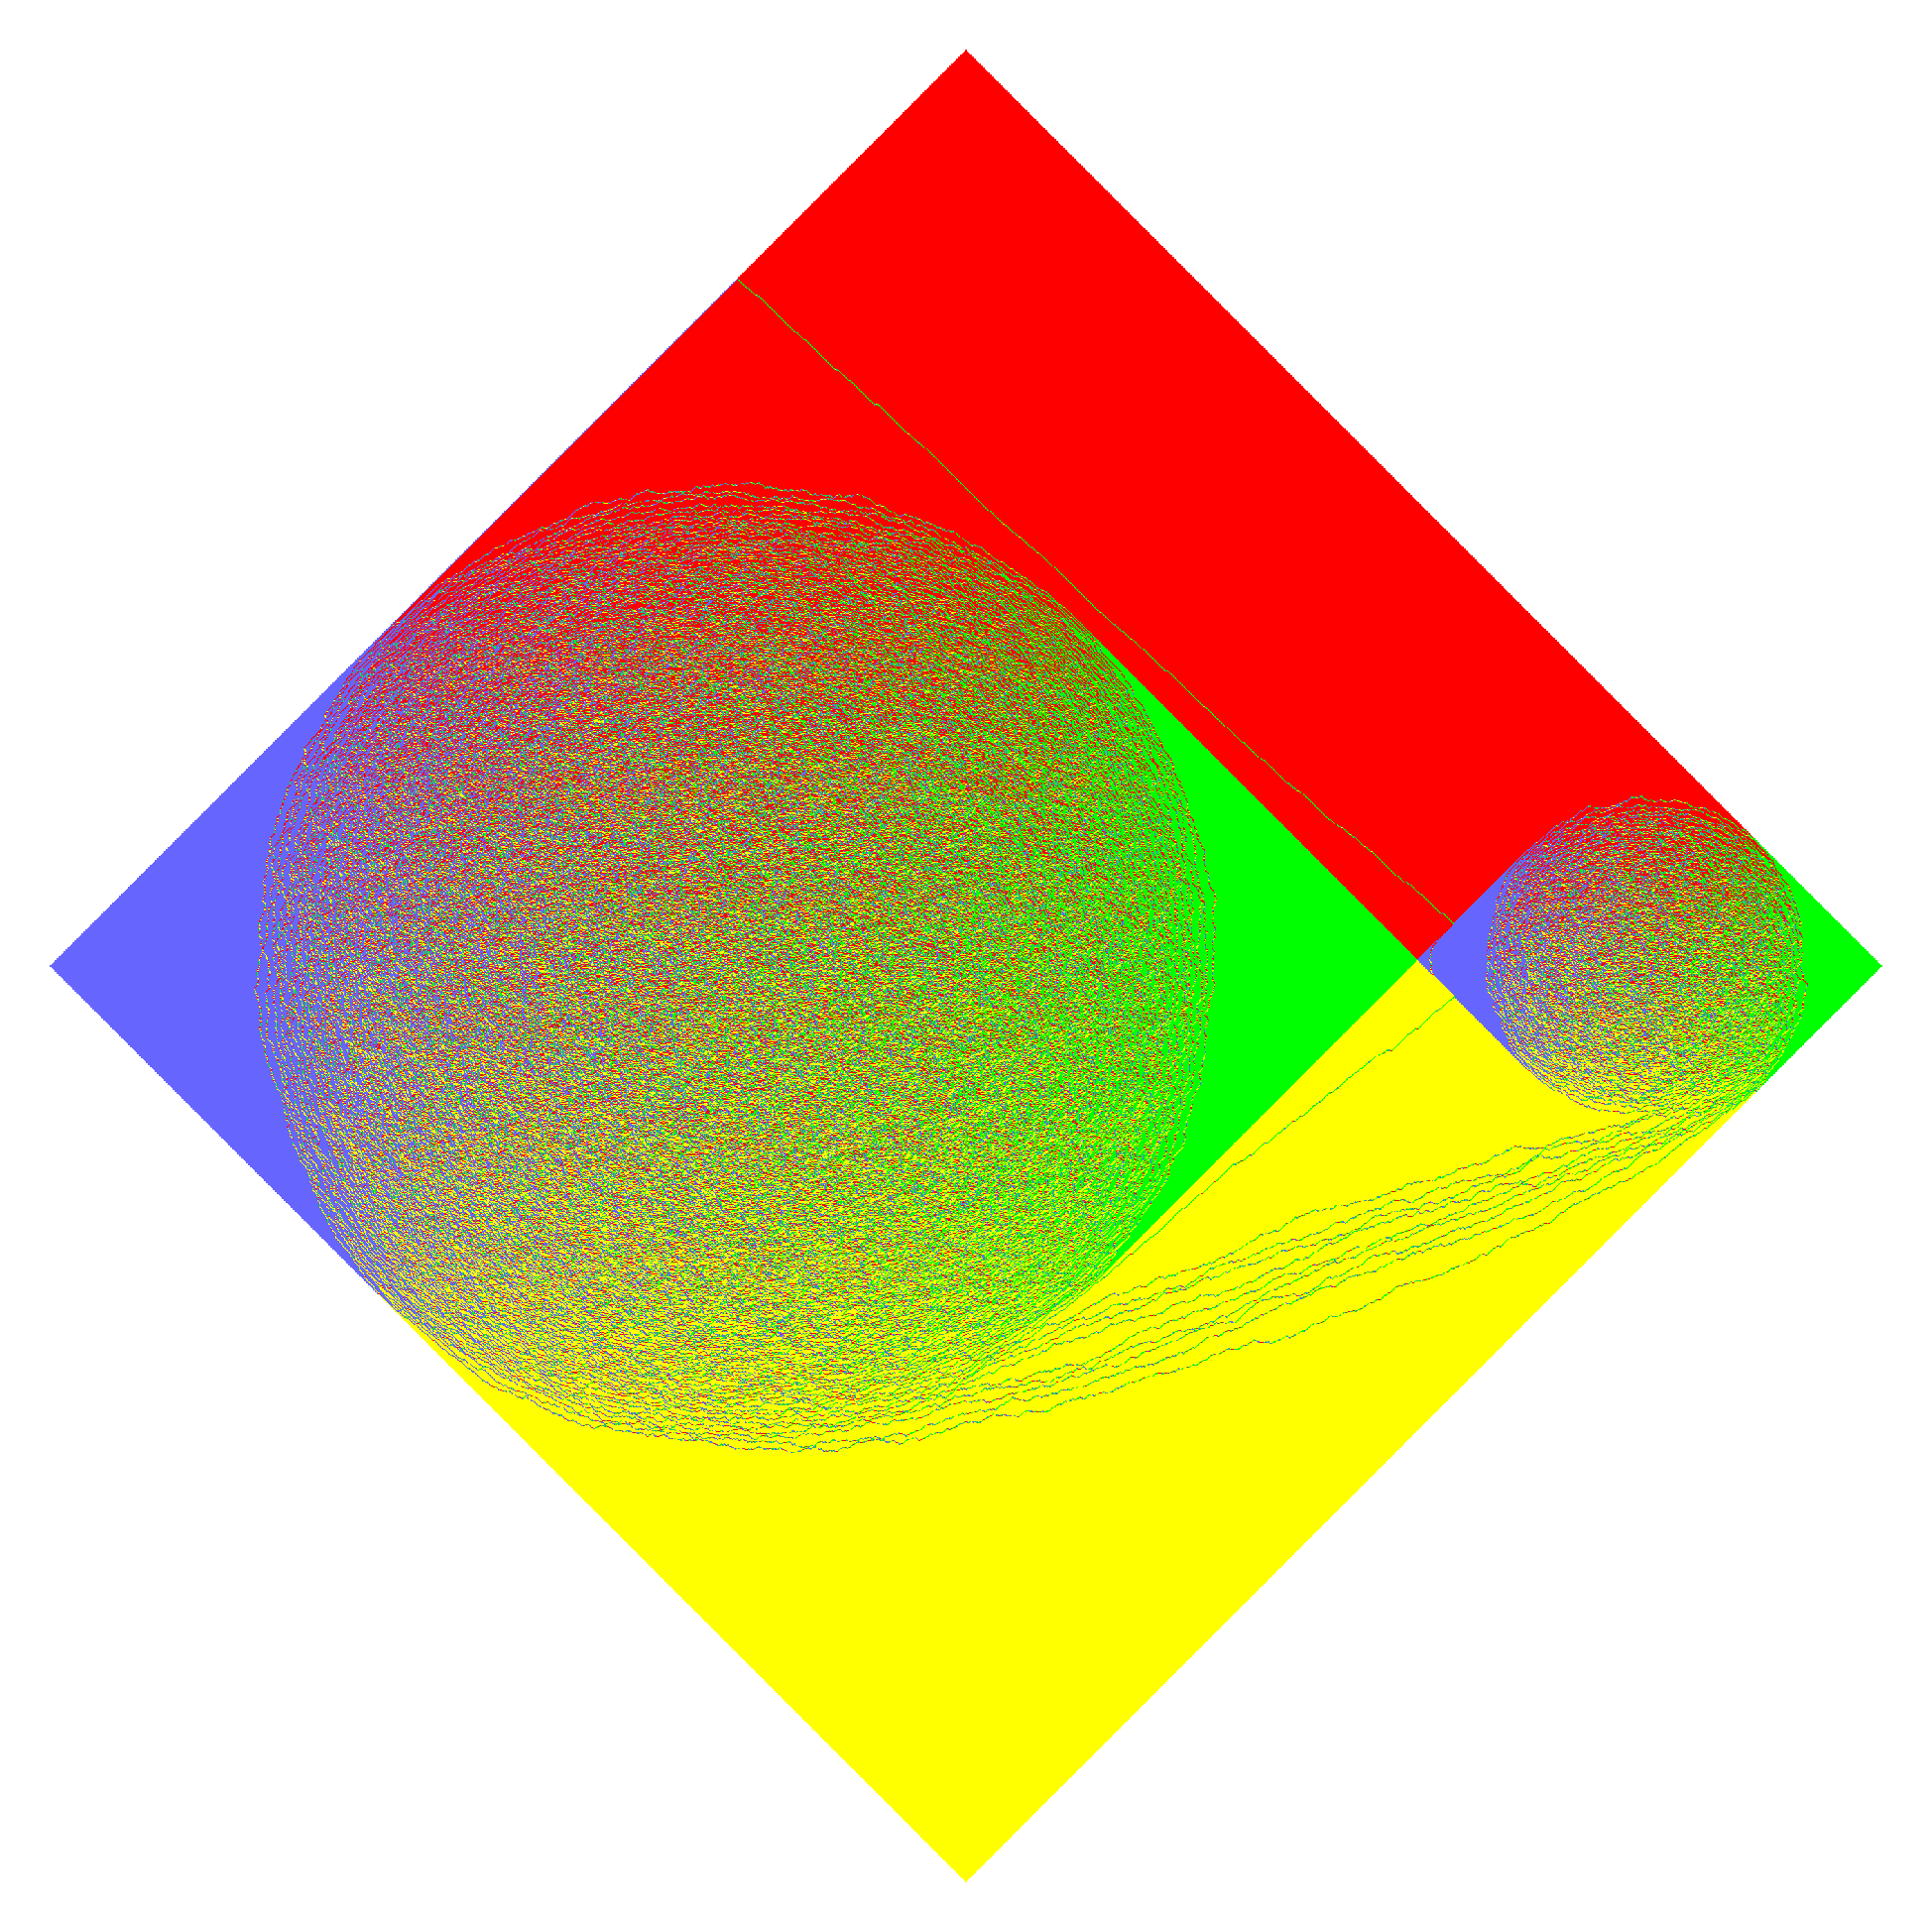

In [99]:
n = 1335
 # n = 1500 -> time: 52s
w = np.array([[1]])
gap = np.array([[int(225/300*2*n),10,1000]])

_ = draw_aztec_gap1(n,w,gap,dpi=500)
#print(Ci)

# Try CTower Harddrive for Gap - Old version

In [7]:
import os
from tqdm import tqdm

def clear_CTower():
    folder_path = "CTower"

    for filename in os.listdir(folder_path):
        file_path = os.path.join(folder_path, filename)
        
        if os.path.isfile(file_path):
            os.remove(file_path)

In [53]:
from RandomTilings.reduction import reduction as red_classic
from RandomTilings.probability_matching_2times2 import probability_matching_2times2
from RandomTilings.ids_procedure import ids_procedure
from RandomTilings.creation import creation

def reduce_weight_hd(W):
    clear_CTower()
    N = W.shape[0] // 2
    C = W + (1+1j)*(W == 0)
    np.save('CTower/'+str(N-1),C)
    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"
    for k in tqdm(range(N-2, -1,-1),desc="Reduction",bar_format=bar_format):
        C = red_classic(C)
        np.save('CTower/'+str(k),C)
    return


def shuffling_hd(Clength):
    C = np.load('CTower/0.npy')
    if np.random.rand() <= probability_matching_2times2(C[0,0],C[1,0],C[0,1],C[1,1]): 
        M = np.array([[1,0],[0,1]])
    else:
        M = np.array([[0,1],[1,0]])
    bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"
    for k in tqdm(range(1,Clength),desc="Shuffling",bar_format=bar_format):
        C = np.load('CTower/'+str(k)+'.npy').astype('complex')
        M = ids_procedure(M)
        M = creation(M,C) 
    return M

def draw_aztec_gap_hd(n,w,gap,edge=0,paths=False,dots=False,rotated=True,coloring='standard',show_gap=False,dpi=200,show_figure=True):
    N = 2*n
    end = N

    w = w.astype(float)
    edge = str(edge)
    W = weight_aztec.weight_aztec(n,w)

    size_gap = gap.shape[0]
    for i1 in range(size_gap):
        X = gap[i1][0]
        for Y in range(gap[i1][1],gap[i1][2]+1):
            if X%2 == 0:
                xSouth = X+1
                ySouth = N-X+2*Y-1
                if 1 <= N-(ySouth-1) and N-(ySouth-1) <= N and 1 <= xSouth and xSouth <= N:
                    W[end-ySouth,xSouth-1] = 0
                xWest = X+1; yWest = N-X+2*Y
                if 1 <= N-(yWest-1) and N-(yWest-1) <= N and 1 <= xWest and xWest <= N:
                    W[end-yWest,xWest-1] = 0
            elif X%2 == 1:
                xSouth = X; ySouth = N-X+2*Y
                if 1 <= N-(ySouth-1) and N-(ySouth-1) <= N and 1 <= xSouth and xSouth <= N:
                    W[end-ySouth,xSouth-1] = 0
                xWest = X; yWest = N-X+2*Y-1
                if 1 <= N-(yWest-1) and N-(yWest-1) <= N and 1 <= xWest and xWest <= N:
                    W[end-yWest,xWest-1] = 0

    C = reduce_weight_hd(W)
    
    M = shuffling_hd(W.shape[0] // 2)
    fig = draw_dominos.draw_dominos(M,gap,edge,paths,dots,rotated,coloring,show_gap,dpi,show_figure)
    return  fig

Shuffling: 100%|██████████| 1334/1334 [12:22<00:00]


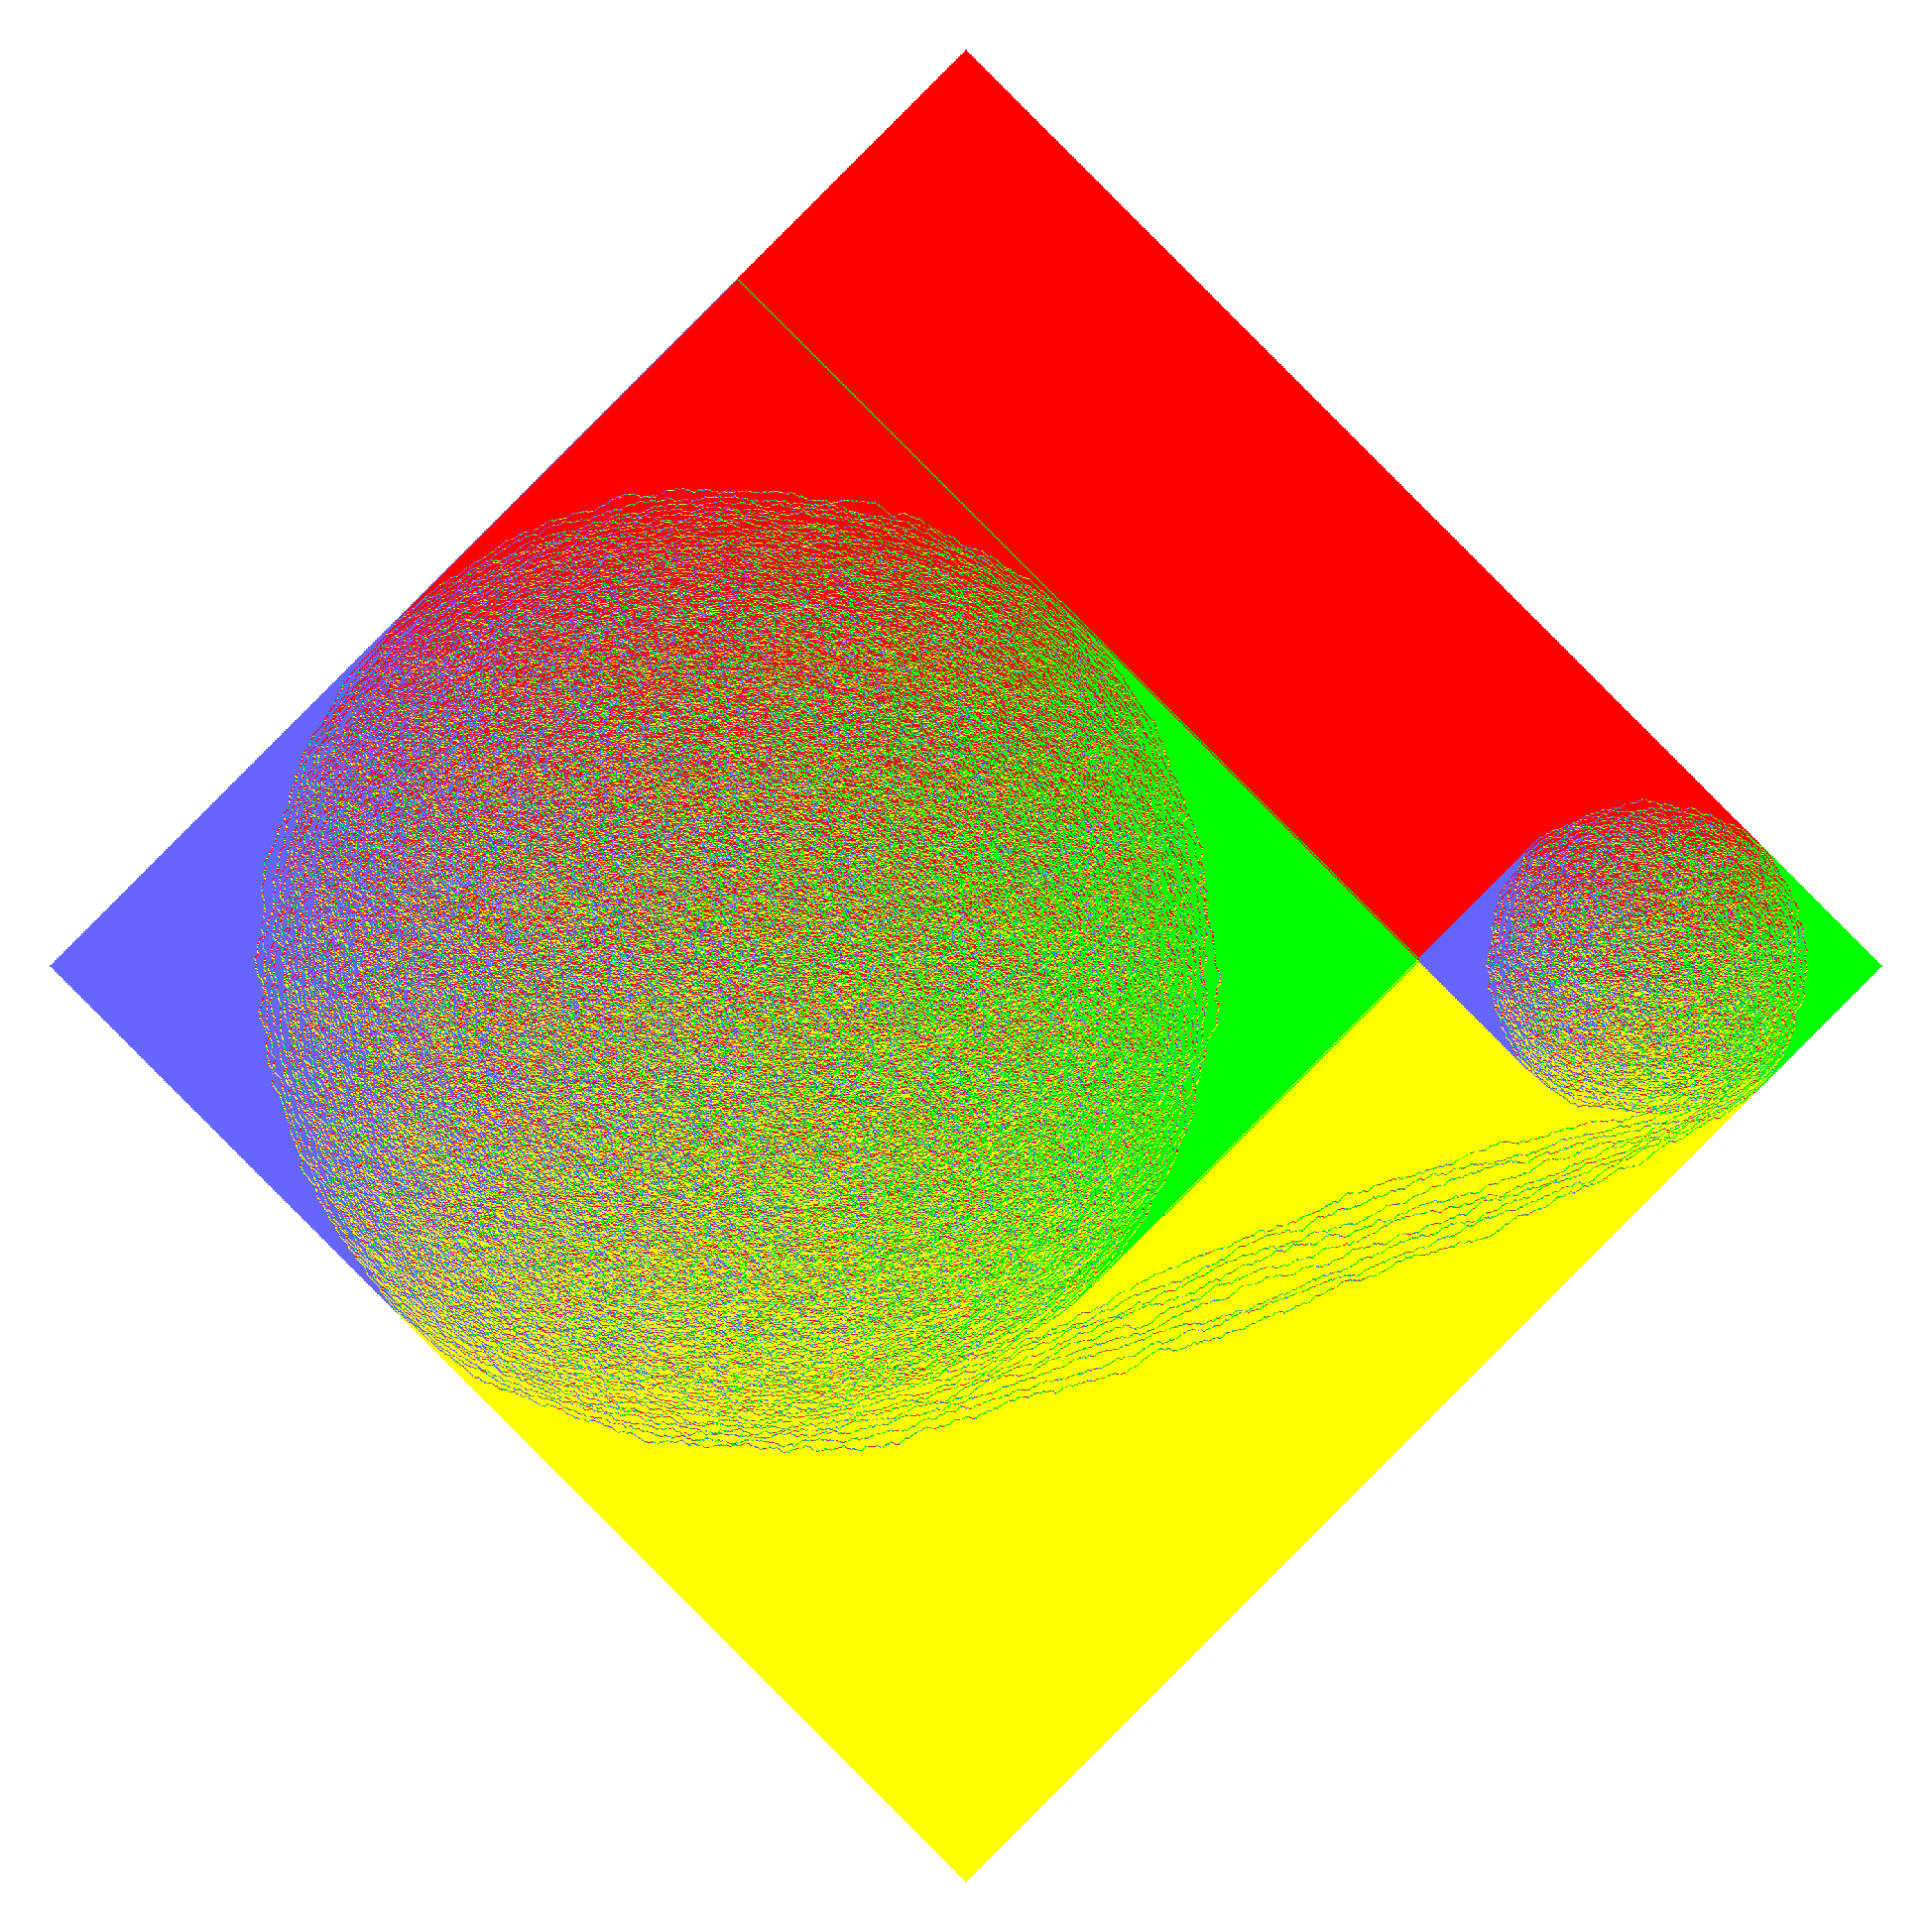

In [93]:

n = 1335 # n = 1500 -> time: 52s
w = np.array([[1]])
gap = np.array([[int(225/300*2*n),10,1000]])

_ = draw_aztec_gap_hd(n,w,gap,dpi=500)

In [12]:
# n = 1500 -> time: 47s
M = draw_aztec_gap1_M_with_C(Ci)

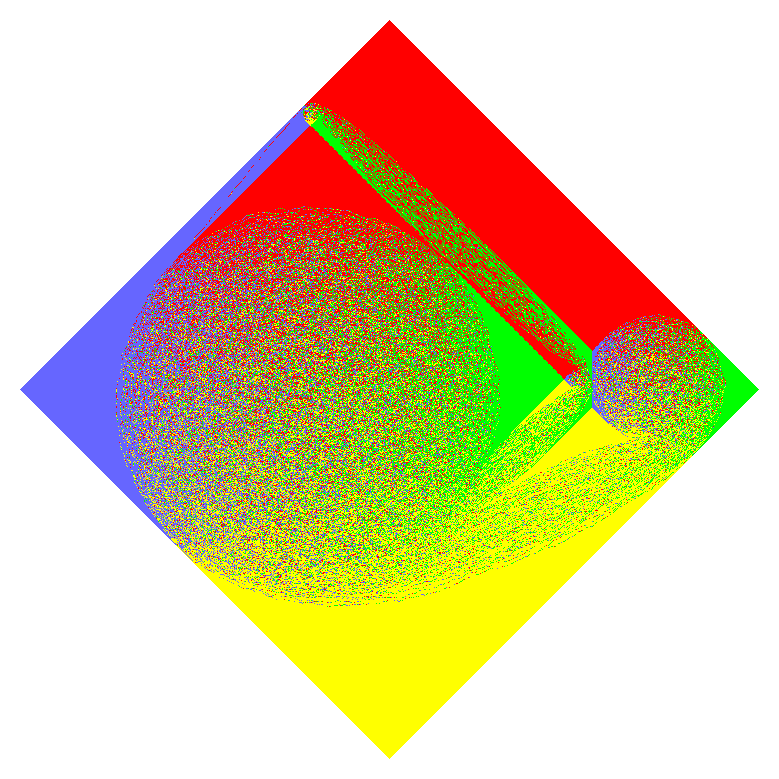

In [13]:
# n = 1500 -> time: 2m13s
M = M.astype(int)
fig = draw_dominos.draw_dominos(M,gap,'0',False,False,True,'standard',True,200,True)